## Prédiction du prix des billets d'avion

L'objectif de ce projet est de predire ***le prix des billets d'avion*** en fonction de diverses caracteristiques telles que la **date de réservation**, **la durée du vol**,**le nombre d'escales**, etc.   
Nous allons mener des anlyses de données pour comprendres les relations entre les diffrentes variables et le prix des billets. Ensuite construire un modele prédictif pour estimer le prix des billets en fonction des caracteristique disponibles.  

L'objectif est d'être capable de predire le prix des billets d'avion avec un erreur moyenne raisonnable.  


### Sommaire

* **Les données**
* **Analyse technique** 
   * **Analyse univariée** 
   * **Analyse multivarié** 
* **Formuler et tester des hypothse** 
* **Préprocessing**
* **Modelisation** 
* **Eavluation finale du modèle**


## Import 

In [3]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.model_selection import cross_validate, KFold


### Analyse fondammenatale

Le Dataset provient de kaggle, et est disponible [ici](https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction), c'est le dataset Clean_Dataset.csv  
**Quoi** :Un dataset de 300 261 reservation de vols distinctes, extrait d’un site web, couvrant des vols programmés entre les plus grandes villes.  
**Quand** : Données collecté sur une periode de 50 jours, du 11 fevrier au 31 decembre mars 2022  
**Ou**: Les données proviennent du site web **Ease my trip**  
**Comment** : Scrapping avec l'outils Octoparse. Les données ont été collecté en deux parties : une pour les billets de classe économique et l'autre pour les billets de classe affairres.

In [4]:
df_original = pd.read_csv('../../Clean_Dataset/Clean_Dataset.csv', index_col=0)
df_original.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


### Analyse technique du jeu de données 

Cette étape sert à determiner ce qui est faisable en analyse univariée et multivariée 
l'objectif est double :
   1. **Identifie le type de chaque variable**  
    - Variable discrete   
    - Variable continue 
    - Date ? Texte libre 
    - Fausses quantités ? (ex: durée exprime enn string)

   2. **Identifier ce que l'on peut faire avec chacune d'elles** 
   -> Est-ce qu'on peut calculer des Statistiques   
   -> Est-ce qu'on peut comparer des categories ?  
   -> Est-ce qu'on doit transformer des colonnes avant toutes analyse ?  

#### Classification des variables (Discrete /continue/autre)

* **airline**        -> Discrete(Catégorielle)   
* **flight**         -> Discrete(Catégorielle)   
* **source_city**    -> Discrete(Catégorielle) 
* **departure_time** -> Discrete(catégorielle Ordinale) 
* **stops**          -> Discrete(Nuemerique Ordinale) 
* **arrival_time**   -> Discrete(catégorielle Ordinale) 
* **destination_city**-> Discrete(Catégorielle) 
* **class**          -> Discrete(Ordinale) 
* **duration**  -> Continue(numérique)
* **days_left**	-> Continue(numérique)
* **price**     -> Continue(numérique) variable cible


In [5]:
discrete_cols = ["airline", "flight", "source_city","departure_time", "stops", "arrival_time","destination_city", "class" ]
continues_cols = ["duration", "days_left", "price"]


In [6]:
# Comptage rapide des Catégories pour les variables discrètes  
for col in discrete_cols:
    print(f"\n---{col}--")
    print(df_original[col].value_counts().head())


---airline--
airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
Name: count, dtype: int64

---flight--
flight
UK-706    3235
UK-772    2741
UK-720    2650
UK-836    2542
UK-822    2468
Name: count, dtype: int64

---source_city--
source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Name: count, dtype: int64

---departure_time--
departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Name: count, dtype: int64

---stops--
stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

---arrival_time--
arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Name: count, dtype: int64

---destination_city--
destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyde

### Analyse Univariée 
Maintenant que les variables ont été classé, on commence l'analyse statistique variable par variable. 

L'objectif est ici :

* Pour les variables discretes : on liste les effectifs et visualise les catégories majoritaires/minoritaires.
* Pour les variables continues : voir la distribution, les valeurs extrêmes, les asymetries, etc. 

In [7]:
def univ_analysis_discrete(col_name, max_unique=20):
    print(f"\n===={col_name}===")
    display(df_original[col_name].value_counts())
    #bar plot
    plt.figure(figsize=(10,5))
    if df_original[col_name].nunique() <= max_unique:
        df_original[col_name].value_counts().plot(kind='bar')
        plt.title(f"Distribution of {col_name}")
        plt.xlabel(col_name)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
    else:
        df_original[col_name].value_counts().nlargest(max_unique).plot(kind='bar')
        plt.title(f"Distribution of {col_name}")
        plt.xlabel(col_name)
        plt.ylabel("Count")
        plt.xticks(rotation=45)
    plt.show()

def univ_analysis_continue(col_name, nbins=30):
    print(f"\n/----{col_name}----/")
    display(df_original[col_name].describe())
    #box plot and histogram
    
    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    df_original[col_name].plot(kind="box")
    plt.title(f"Distribution {col_name}")
    # plt.xlabel(col_name)
    plt.ylabel("Count")
    plt.subplot(1,2,2)
    df_original[col_name].hist(bins=nbins)
    plt.title(f"Histograme pour {col_name}")
    plt.xlabel(col_name)
    plt.ylabel("Fréquence")
    plt.show()
    

#### Price
Analyse de la variable cible


/----price----/


count    300153.000000
mean      20889.660523
std       22697.767366
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64

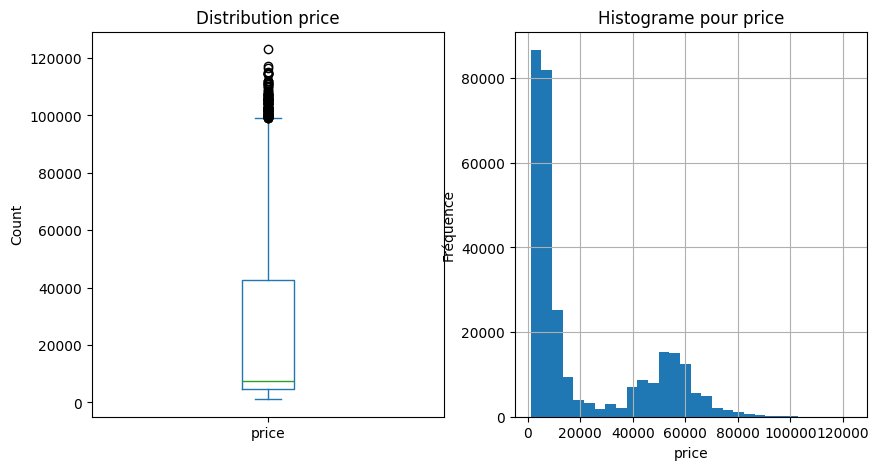

In [8]:
univ_analysis_continue("price")

* La moyenne du prix est 20889 Roupie, mais la mediane est à 7425 Roupie, ce qui indique une distribution asymetrique avec une longue queue à droite (quelques billets très chers). C'est ce qu'on observe dans l'histogramme.
* Les deux groupes de prix correspondens en fait aux classes économique et business 

#### Airline


====airline===


airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

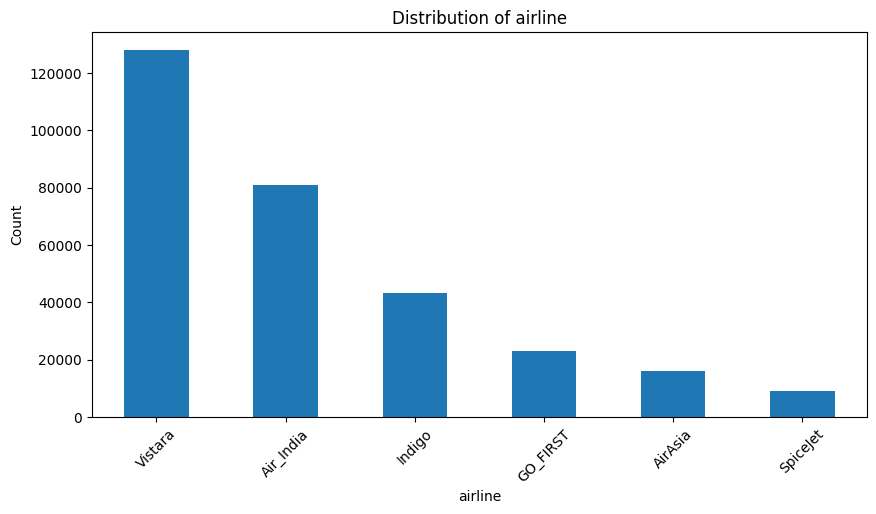

In [9]:
univ_analysis_discrete('airline')

* Nous constatons la compagnie Vistara est dominante dans notre jeu de données  
* Variable discrete à forte part de marché inégale.
* Impact probable sur le prix ->

#### Source_city


====source_city===


source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

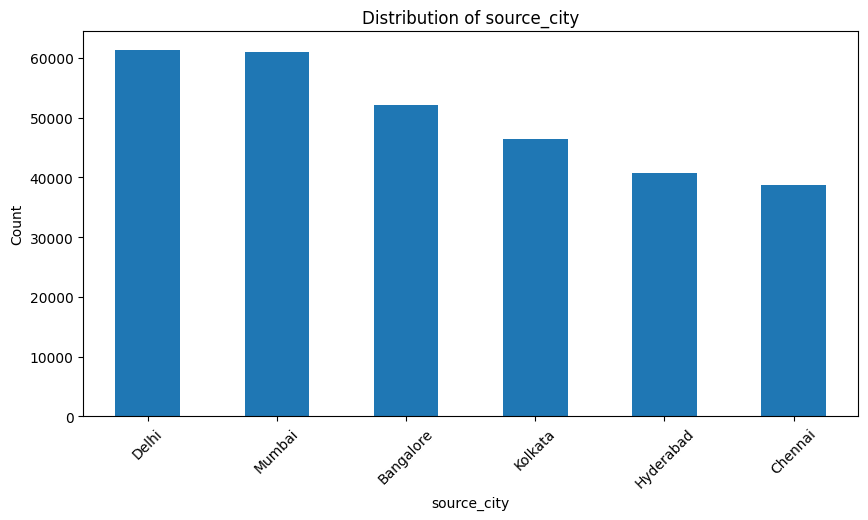

In [10]:
univ_analysis_discrete("source_city")

#### Departure_time


====departure_time===


departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

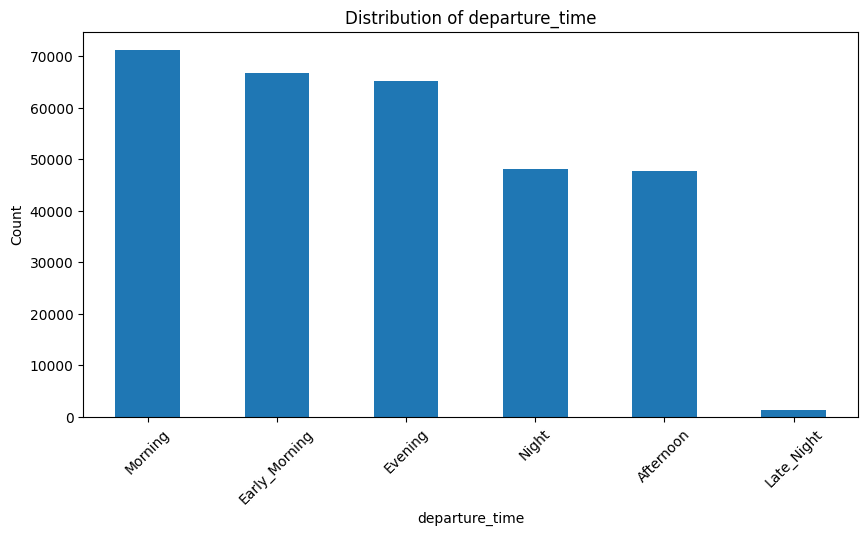

In [11]:
univ_analysis_discrete("departure_time")

Trés peu de vol tardive

#### Stops


====stops===


stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64

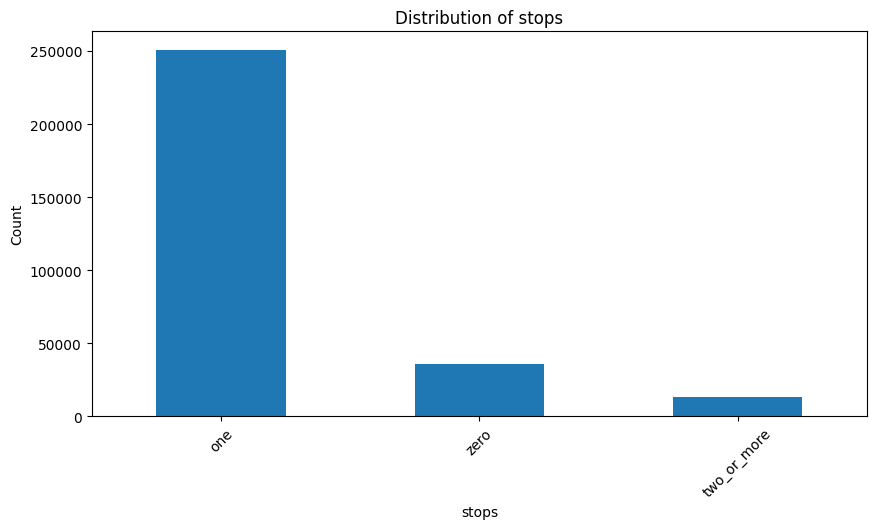

In [12]:
univ_analysis_discrete("stops")

La plupart des vols font un escale

Le temps d'arrivé


====arrival_time===


arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: count, dtype: int64

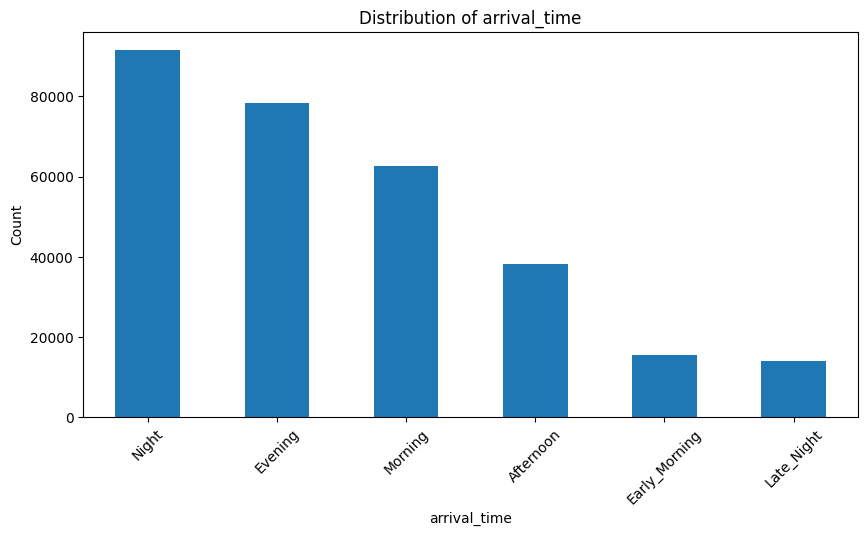

In [13]:
univ_analysis_discrete('arrival_time')

Beaucoup de vol arrive tard la nuit 

#### L'aeroport d'arrivé


====destination_city===


destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64

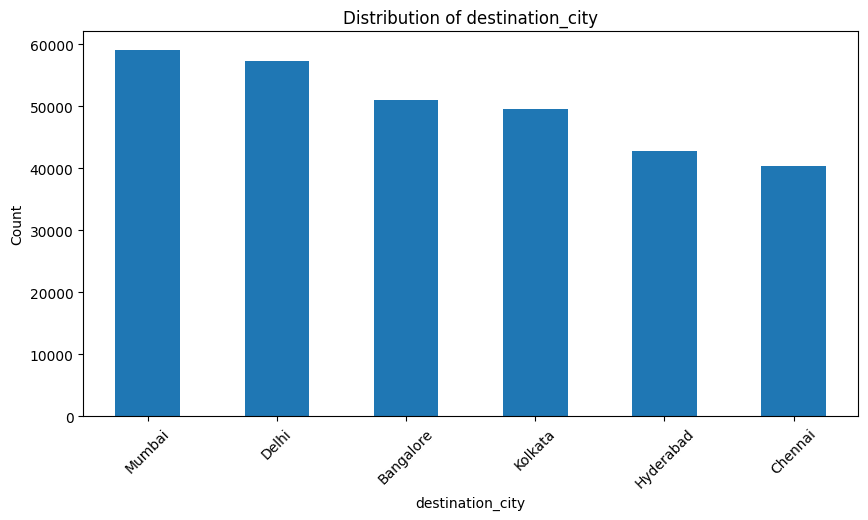

In [14]:
univ_analysis_discrete("destination_city")

#### Class 


====class===


class
Economy     206666
Business     93487
Name: count, dtype: int64

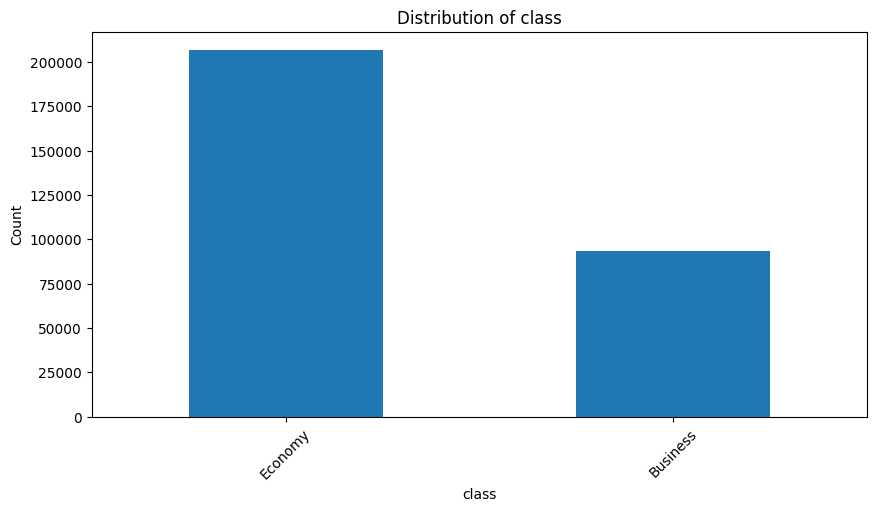

In [15]:
univ_analysis_discrete("class")

A peu près deux fois plus de billet en classe économique qu'en classe business.

#### Duration 


/----duration----/


count    300153.000000
mean         12.221021
std           7.191997
min           0.830000
25%           6.830000
50%          11.250000
75%          16.170000
max          49.830000
Name: duration, dtype: float64

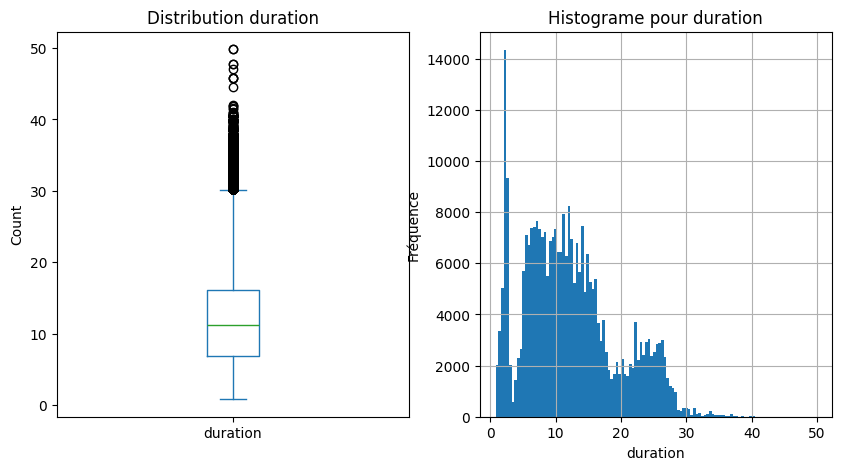

In [16]:
univ_analysis_continue("duration", nbins=120)

### Analyse multivariée 

##### a. Relation entre le prix et la durée du vol

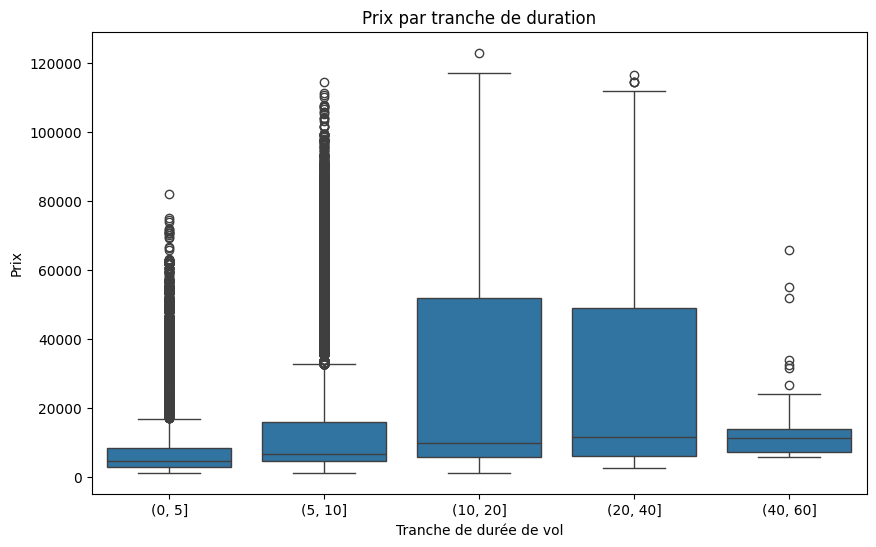

In [17]:
df_original["duration_bin"] = pd.cut(df_original["duration"], bins=[0,5,10,20,40,60])

plt.figure(figsize=(10,6))
sns.boxplot(x="duration_bin", y="price", data=df_original)
plt.title("Prix par tranche de duration")
plt.xlabel("Tranche de durée de vol")
plt.ylabel("Prix")
plt.show()

On remarque que les prix moyens semblent varier positivement avec la durée du vol.

#### b. Relation entre le prix et la compagnie aerienne 

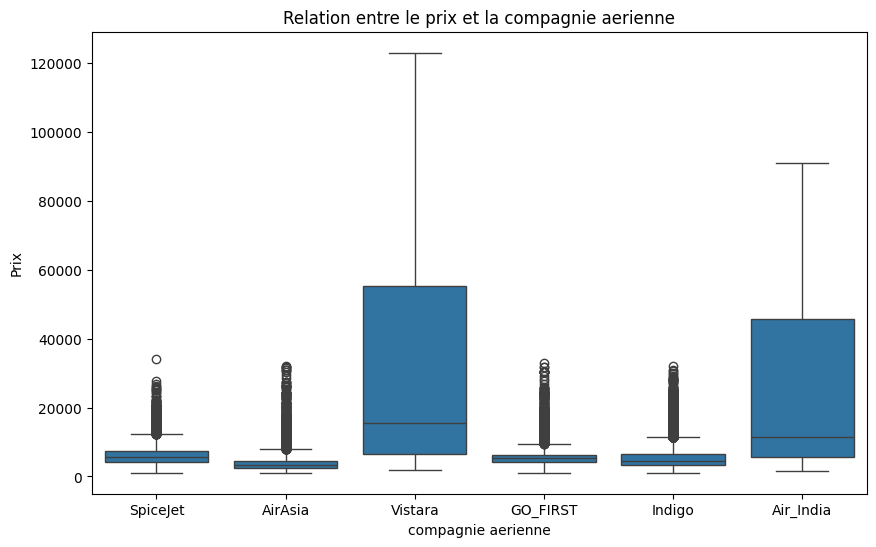

In [20]:
plt.figure(figsize=(10,6))
sns.boxplot(x="airline", y="price", data=df_original)
plt.title("Relation entre le prix et la compagnie aerienne")
plt.xlabel("compagnie aerienne")
plt.ylabel("Prix")
plt.show()

On remarque que pour certaines compagnie comme **Vistara et air india** le prix de billet relativement être plus élévé que les autre compagnie, donc nous pouvons mettre un hypothèse que la compagnie aerienne semble avoir un impact significatif sur le prix de billet 

#### c. Relation entre le nombre d'escale et le prix

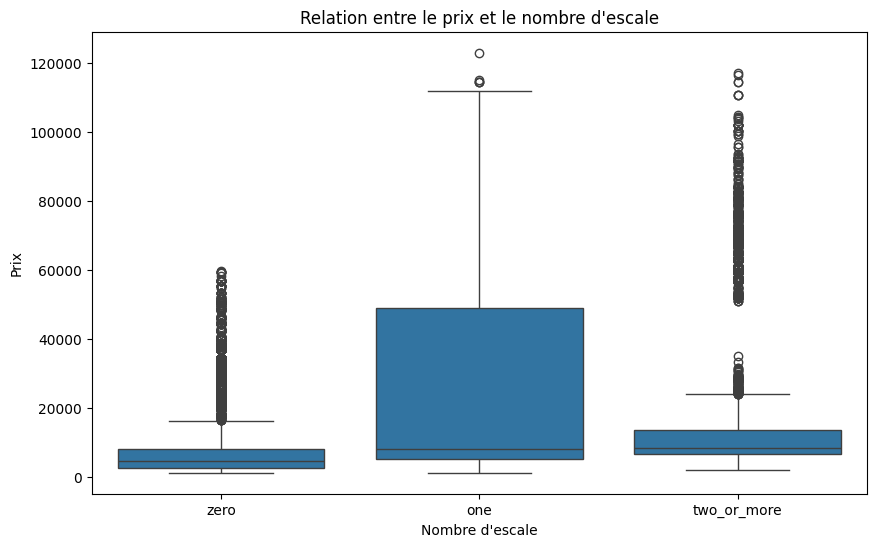

In [21]:
plt.figure(figsize=(10,6))
sns.boxplot(x="stops", y="price", data=df_original)
plt.title("Relation entre le prix et le nombre d'escale")
plt.xlabel("Nombre d'escale")
plt.ylabel("Prix")
plt.show()

En moyenne, le prix est plus élévé pour les vols avec au moins un escale. Cependant, il y'a une grade variabilité des prix pour chaque catégorie d'escales, indiquant que d'autre facteur influencent également le prix des billets. 

##### d. Relation entre le nombre de jours entre la reservation et le vol et le prix 

Text(0, 0.5, 'Prix')

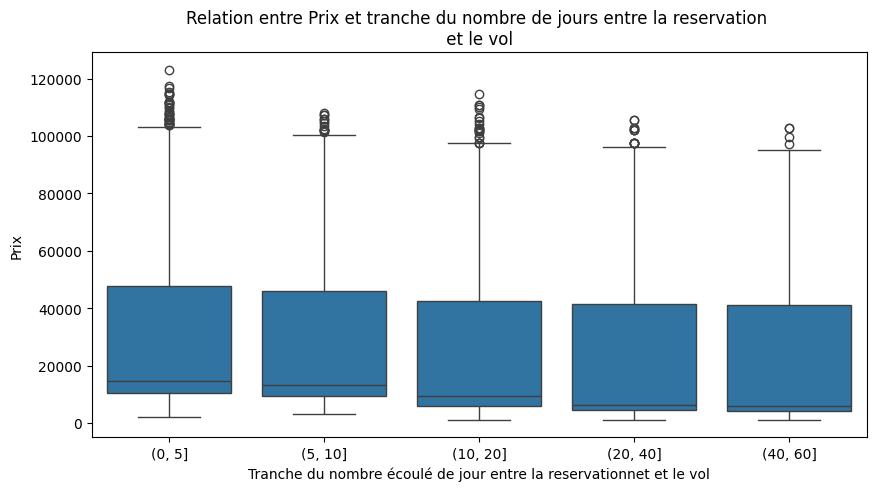

In [32]:
df_original["days_bins"] = pd.cut(df_original["days_left"],bins=[0,5,10,20,40,60])

plt.figure(figsize=(10,5))
sns.boxplot(data=df_original, x="days_bins", y="price")
plt.title("Relation entre Prix et tranche du nombre de jours entre la reservation \n et le vol ")
plt.xlabel("Tranche du nombre écoulé de jour entre la reservationnet et le vol")
plt.ylabel("Prix")


En moyenne le prix tend à diminuer avec le nombre de jours entre la reservation et le vol. Reservé tôt semble associé à des prix plus bas. 

### Formuler et test des hypothèses 

Après l'analyse technique, univarié et multivarié, on va formuler des **hypothèse statistique et les tester**. L'idée est pertir de nos observation précedentes et de les transformer en hypothèse, que l'on va ensuite valider ou non.

In [33]:
alpha = 0.05

A partir des graphiques et des statistiques calculées précedemment, on retient es observations suivantes :  

1. Durée du vol vs Prix

Question : Les vols les plus longs sont-ils associé à des prix plus éléve ?   
On teste l'existence d'une correlation linéaire entre : 
* `duration`(variable continue)
* `price`(variable continue)

**Hypothèse:**
- $H_0$ : la correlation linéaire entre `duration` et `price` est nulle. -> (*La durée du vol n’influence pas le prix*.)
- $H_1$ : la correlation linéaire entre `duration` et `price` est non null.-> (*La durée du vol influence le prix*)

On utilise le **test de personn**

In [37]:
# Test de correlation entre duration et price
corr_duration_price, p_value_duration_price = stats.pearsonr(df_original["duration"], df_original["price"])

print("Correlation (duration, price):", corr_duration_price)
print("p-value:", p_value_duration_price)

if p_value_duration_price < alpha:
    print(f"-> p-value < {alpha} : on rejette H0.")
    print("Conclusion : la durée du vol influence le prix")
    
else:
    print(f"-> p-value > {alpha}: on ne rejette pas H0")
    print("Conclusion: on ne met pas evidence entre le correlationn linéaire significative entre la durée du vol et le prix")

Correlation (duration, price): 0.2042223678454271
p-value: 0.0
-> p-value < 0.05 : on rejette H0.
Conclusion : la durée du vol influence le prix


2. Compagnie aerienne vs Prix
Question : les differentes compagnie pratiquent-elles en moyenne le même niveau de prix ?
- Variable discrete : `airline`
- Variable continue : `Price`

##### Hypothèses : 
- $H_0$ : le prix moyen des billets est le même pour toutes les compagnies.
- $H_1$ : au moins une des compagnies a prix moyen different des autres. 

On utlise un **test d'Anova (f_oneway)**


In [39]:
f_stat_airline, p_value_airline = stats.f_oneway(*df_original.groupby("airline",observed=False)["price"].apply(list))
print("Statistique F(airline vs price):", f_stat_airline)
print("p-value:", p_value_airline)

if p_value_airline < alpha:
    print(f"-> p-value < {alpha}: on rejette H0.")
    print("Conclusion : le prix moyen n'est pas le même pour toutes ces compagnies(aumoins une se distingue)")
else:
    print(f"-> p-value >= {alpha}")
    print("Conclusion : nous n'avons pas de preuve suffisante pour dire que le prix moyen diffère entre ces compagnies")

Statistique F(airline vs price): 17194.402096092366
p-value: 0.0
-> p-value < 0.05: on rejette H0.
Conclusion : le prix moyen n'est pas le même pour toutes ces compagnies(aumoins une se distingue)


##### 3. Nombre d'escales vs Prix

**Question: le prix moyen est-il identique quel que soit le nombre d'escales ?**
* Variable discrète : stops
* Variable continue : price

Hypothèse :
* $H_0$ : le prix moyen des billets est le même pour tous les niveaux d'escales.
* $H_1:$ le prix moyen des buillets dépend du nombre d'escales.

Nous utilise un **test d'anova** 

In [42]:
print("Valeurs de 'stops' : ['One', 'two_or_more', 'zero']")
f_stat_stops_price, p_value_stops_price = stats.f_oneway(*df_original.groupby("stops",observed=False)["price"].apply(list))
print("Statistique F(stops vs price):", f_stat_stops_price)
print("p-value:", p_value_stops_price)

if p_value_stops_price < alpha:
    print(f"-> p-value < {alpha}: on rejette H0.")
    print("Conclusion : le prix moyen depend du nombre d'escales")
else:
    print(f"-> p-value >= {alpha}")
    print("Conclusion : nous n'avons pas de preuve suffisante pour dire le prix moyen des billets dépend du nombre d'escales")

Valeurs de 'stops' : ['One', 'two_or_more', 'zero']
Statistique F(stops vs price): 6477.130362486244
p-value: 0.0
-> p-value < 0.05: on rejette H0.
Conclusion : le prix moyen depend du nombre d'escales


##### 4. Nombre de jours avant le vol vs Prix

**Question** : Réserver plus tôt est-il associé à des prix plus bas ?

- variable continue `days_left`
- variable continue `price`

On utilise un test de personn 

- $H_0$ : il n'existe pas de correlation linéaire entre `days_left` et `price`.
- $H_1$ : il existe une correlation linéaire entre dats_left et price 

In [44]:
# Test la correlation entre le prix et le nombre de jour avant le vol

corr_day_left_price, p_value_day_left_price = stats.pearsonr(df_original["price"], df_original["days_left"])

print("Correlation (duration, price):", corr_day_left_price)
print("p-value:", p_value_day_left_price)

if p_value_day_left_price < alpha:
    print(f"-> p-value < {alpha} : on rejette H0.")
    print("Conclusion : il existe une correlation linéaire significative entre le nombre jours avant le vol et le prix")
    
else:
    print(f"-> p-value > {alpha}: on ne rejette pas H0")
    print("Conclusion: on ne met pas evidence entre le correlationn linéaire significative entre le nombre avant le vol et le prix")

Correlation (duration, price): -0.09194853217143847
p-value: 0.0
-> p-value < 0.05 : on rejette H0.
Conclusion : il existe une correlation linéaire significative entre le nombre jours avant le vol et le prix
